# Task 1 (MusicCaps variant) - BERT Caption-to-Tag Classifier

Multi-label tag classifier on **MusicCaps** natural-language captions 


In [1]:
# 1. Install and import dependencies
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("datasets") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "datasets"])

import ast
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
# 2. Configure paths and training parameters
SEED = 42
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 2e-5
HEAD_LEARNING_RATE_MULTIPLIER = 10
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 8
SEQ_LEN = 64            # captions are longer than tag lists, but still short sentences
TOP_K_ASPECTS = 50       # match the MTT notebooks' 50-tag setup for comparability
CLASSIFICATION_THRESHOLD = 0.5

BERT_MODEL_NAME = "bert-base-uncased"
OUTPUT_DIR = Path("/kaggle/working/task1_musiccaps_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"Outputs: {OUTPUT_DIR}")

# Prefer a local BERT snapshot if one happens to be attached as a Kaggle input.
# Kaggle dataset uploads often flatten the folder structure, so match on file
# contents (tokenizer_config.json + weights) rather than a specific folder name.
for candidate in Path("/kaggle/input").glob("**/tokenizer_config.json"):
    snapshot_dir = candidate.parent
    has_weights = (snapshot_dir / "model.safetensors").exists() or (snapshot_dir / "pytorch_model.bin").exists()
    if has_weights:
        BERT_MODEL_NAME = str(snapshot_dir)
        print(f"Using local BERT snapshot: {snapshot_dir}")
        break
else:
    print(f"No local BERT snapshot found; will download '{BERT_MODEL_NAME}' from Hugging Face.")


# 3. Load MusicCaps metadata from a local Kaggle input (text/labels only, no audio needed for Task 1)
musiccaps_csv = next(Path("/kaggle/input").glob("**/musiccaps*.csv"), None)

if musiccaps_csv is not None:
    print(f"Using local MusicCaps CSV: {musiccaps_csv}")
    records = pd.read_csv(musiccaps_csv)
else:
    # Fall back to the Hugging Face Hub (requires Kaggle "Internet" to be enabled).
    from datasets import load_dataset

    musiccaps = load_dataset("google/MusicCaps", split="train")
    records = musiccaps.to_pandas()

print(f"Loaded {len(records):,} MusicCaps records")
records.head(3)


Device: cuda
Outputs: /kaggle/working/task1_musiccaps_results
No local BERT snapshot found; will download 'bert-base-uncased' from Hugging Face.
Using local MusicCaps CSV: /kaggle/input/datasets/googleai/musiccaps/musiccaps-public.csv
Loaded 5,521 MusicCaps records


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True


In [3]:
# 4. Build the top-K aspect-tag vocabulary and multi-hot label matrix
def parse_aspects(value):
    if isinstance(value, (list, np.ndarray)):
        return [str(item).strip().lower() for item in value]
    return [item.strip().lower() for item in ast.literal_eval(value)]


records["aspects"] = records["aspect_list"].apply(parse_aspects)
records = records[records["aspects"].apply(len) > 0].reset_index(drop=True)

aspect_counts = Counter(aspect for aspects in records["aspects"] for aspect in aspects)
tag_names = [name for name, _ in aspect_counts.most_common(TOP_K_ASPECTS)]
tag_to_index = {name: index for index, name in enumerate(tag_names)}
NUM_TAGS = len(tag_names)

labels = np.zeros((len(records), NUM_TAGS), dtype=np.float32)
for row_index, aspects in enumerate(records["aspects"]):
    for aspect in aspects:
        if aspect in tag_to_index:
            labels[row_index, tag_to_index[aspect]] = 1.0

# Drop rows that ended up with none of the top-K aspects present.
keep_mask = labels.sum(axis=1) > 0
records = records[keep_mask].reset_index(drop=True)
labels = labels[keep_mask]
captions = records["caption"].tolist()

TAG_NAMES_PATH = OUTPUT_DIR / "musiccaps_tag_names.json"
with TAG_NAMES_PATH.open("w", encoding="utf-8") as file:
    json.dump(tag_names, file, indent=2)

print(f"Usable clips: {len(records):,}")
print(f"Top-{NUM_TAGS} aspect tags: {tag_names}")
print(f"Avg active tags per clip: {labels.sum(axis=1).mean():.2f}")


# 5. Reproducible 70/15/15 splits
indices = np.arange(len(records))
train_val_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=SEED)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.15 / 0.85, random_state=SEED)
splits = {"train": train_idx.tolist(), "val": val_idx.tolist(), "test": test_idx.tolist()}

with (OUTPUT_DIR / "musiccaps_splits.json").open("w", encoding="utf-8") as file:
    json.dump(splits, file)

for split_name in ("train", "val", "test"):
    print(f"{split_name:>5}: {len(splits[split_name]):,} clips")


Usable clips: 4,995
Top-50 aspect tags: ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo', 'acoustic drums', 'fast tempo', 'mono', 'groovy', 'bass guitar', 'electric guitar', 'acoustic guitar', 'instrumental music', 'uptempo', 'piano', 'punchy kick', 'poor audio quality', 'punchy snare', 'groovy bass', 'happy', 'male voice', 'moderate tempo', 'e-bass', 'shimmering hi hats', 'male vocal', 'rock', 'percussion', 'no voices', 'youthful', 'pop', 'male singer', 'spirited', 'romantic', 'electronic drums', 'exciting', 'upbeat', 'bass', 'loud', 'mellow', 'keyboard harmony', 'fun', 'cheerful', 'easygoing', 'flat male vocal', 'e-guitar']
Avg active tags per clip: 3.09
train: 3,495 clips
  val: 750 clips
 test: 750 clips


In [4]:
# 6. Caption dataset (no masking needed: captions are independent of the aspect-tag labels)
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)


class CaptionTagDataset(Dataset):
    def __init__(self, captions, labels, tokenizer, max_length):
        self.captions = captions
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.captions[index], padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[index], dtype=torch.float32),
        }


def subset(indices):
    return [captions[i] for i in indices], labels[indices]


train_captions, train_labels = subset(splits["train"])
val_captions, val_labels = subset(splits["val"])
test_captions, test_labels = subset(splits["test"])

train_dataset = CaptionTagDataset(train_captions, train_labels, tokenizer, SEQ_LEN)
val_dataset = CaptionTagDataset(val_captions, val_labels, tokenizer, SEQ_LEN)
test_dataset = CaptionTagDataset(test_captions, test_labels, tokenizer, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(
    f"Batches - train: {len(train_loader):,}, "
    f"validation: {len(val_loader):,}, test: {len(test_loader):,}"
)
print(f"Example caption: {train_captions[0]!r}")


# 7. BERT multi-label classifier (same architecture as the MTT Task 1 notebook)
class BertTagClassifier(nn.Module):
    def __init__(self, model_name, num_tags, hidden_dim=768, dropout=0.1, freeze_layers=8):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_tags)
        for layer_index, layer in enumerate(self.bert.encoder.layer):
            if layer_index < freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = self.dropout(outputs.last_hidden_state[:, 0, :])
        return self.classifier(cls_embedding)


model = BertTagClassifier(BERT_MODEL_NAME, NUM_TAGS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.1f}%)")


# 8. Evaluation function
@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5, return_arrays=False):
    model.eval()
    all_labels, all_scores = [], []
    total_loss, total_examples = 0.0, 0

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        targets = batch["labels"].to(DEVICE)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)

        total_loss += loss.item() * targets.size(0)
        total_examples += targets.size(0)
        all_scores.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(targets.cpu().numpy())

    labels_array = np.concatenate(all_labels)
    scores_array = np.concatenate(all_scores)
    predictions = (scores_array >= threshold).astype(np.int32)

    average_precisions = np.full(labels_array.shape[1], np.nan)
    for tag_index in range(labels_array.shape[1]):
        positives = labels_array[:, tag_index].sum()
        if 0 < positives < len(labels_array):
            average_precisions[tag_index] = average_precision_score(
                labels_array[:, tag_index], scores_array[:, tag_index]
            )

    metrics = {
        "loss": float(total_loss / total_examples),
        "macro_f1": float(f1_score(labels_array, predictions, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(labels_array, predictions, average="micro", zero_division=0)),
        "auc_pr": float(np.nanmean(average_precisions)),
    }
    if return_arrays:
        return metrics, labels_array, scores_array, average_precisions
    return metrics


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches - train: 110, validation: 24, test: 24
Example caption: 'A male singer sings this rap vocals with backup singers in harmony. The song is medium tempo with typing and beeping tones, followed by steady drumming rhythm, groovy bass and keyboard harmony. The song is energetic and exciting. The song has a home video intro followed by a rap song.'


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 109,520,690
Trainable parameters: 52,817,714 (48.2%)


In [5]:
# 9. Train with early stopping
optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": LEARNING_RATE},
    {"params": model.classifier.parameters(), "lr": LEARNING_RATE * HEAD_LEARNING_RATE_MULTIPLIER},
], weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()

CHECKPOINT_PATH = OUTPUT_DIR / "task1_musiccaps_best.pt"
history = []
best_val_auc_pr = float("-inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss, total_train_examples = 0.0, 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
    for batch in progress:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        targets = batch["labels"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item() * targets.size(0)
        total_train_examples += targets.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    train_loss = total_train_loss / total_train_examples
    val_metrics = evaluate(model, val_loader, criterion, threshold=CLASSIFICATION_THRESHOLD)
    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        **{f"val_{name}": value for name, value in val_metrics.items()},
    })

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
        f"macro_f1={val_metrics['macro_f1']:.4f} | micro_f1={val_metrics['micro_f1']:.4f} | "
        f"auc_pr={val_metrics['auc_pr']:.4f}"
    )

    if val_metrics["auc_pr"] > best_val_auc_pr:
        best_val_auc_pr = val_metrics["auc_pr"]
        epochs_without_improvement = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "tag_names": tag_names,
                "validation_metrics": val_metrics,
            },
            CHECKPOINT_PATH,
        )
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after epoch {epoch}")
            break

with (OUTPUT_DIR / "task1_musiccaps_history.json").open("w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

print(f"Best validation AUC-PR: {best_val_auc_pr:.4f}")


Epoch 01/15:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2458 | val_loss=0.1736 | macro_f1=0.0539 | micro_f1=0.2267 | auc_pr=0.2793


Epoch 02/15:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1603 | val_loss=0.1435 | macro_f1=0.1568 | micro_f1=0.3725 | auc_pr=0.4049


Epoch 03/15:   0%|          | 0/110 [00:00<?, ?it/s]

...

Epoch 13 | train_loss=0.0769 | val_loss=0.0918 | macro_f1=0.6163 | micro_f1=0.7135 | auc_pr=0.6755


Epoch 14/15:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 14 | train_loss=0.0764 | val_loss=0.0917 | macro_f1=0.6189 | micro_f1=0.7146 | auc_pr=0.6767


Epoch 15/15:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 15 | train_loss=0.0759 | val_loss=0.0915 | macro_f1=0.6161 | micro_f1=0.7137 | auc_pr=0.6766
Best validation AUC-PR: 0.6767


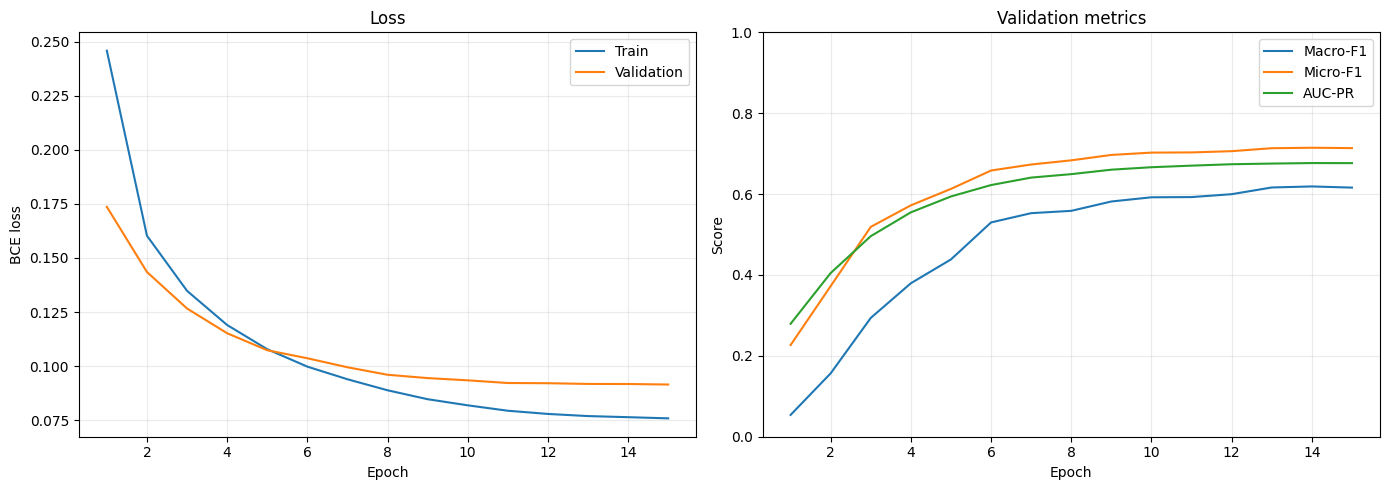

TASK 1 (MusicCaps) — TEST RESULTS
  Macro-F1: 0.6336
  Micro-F1: 0.7184
  AUC-PR:   0.7135

--- Sample 1 ---
  Caption:  This is an opening theme for a TV series. It is an instrumental piece. The main theme is being played by a loud brass section. There is a groovy synth bass line playing. The rhythmic background consists of a strong electronic drum beat. The atmosphere is energetic. This piece could be used in lifting samples for beat-making.
  True tags: ['instrumental', 'energetic', 'electronic drums']
  Top-5 predicted: [('energetic', '0.885'), ('electronic drums', '0.786'), ('instrumental', '0.559'), ('groovy', '0.282'), ('loud', '0.268')]

--- Sample 2 ---
  Caption:  The Folk song features a passionately played sitar guitar, groovy bass and short offbeat accordion chords, followed by metallic percussive elements and punchy kick. The recording is a bit lower in quality due to loud clicky keys sounds. It sounds passionate and emotional.
  True tags: ['low quality', 'emotional', 'p

In [7]:
# 10. Plot loss and validation metrics vs. epoch
history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="Train")
axes[0].plot(history_frame["epoch"], history_frame["val_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="BCE loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

for metric_name, label in (("val_macro_f1", "Macro-F1"), ("val_micro_f1", "Micro-F1"), ("val_auc_pr", "AUC-PR")):
    axes[1].plot(history_frame["epoch"], history_frame[metric_name], label=label)
axes[1].set(title="Validation metrics", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task1_musiccaps_training_history.png", dpi=160, bbox_inches="tight")
plt.show()


# 11. Evaluate the best model on the test set
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

test_metrics, test_labels_array, test_scores, per_tag_ap = evaluate(
    model, test_loader, criterion, threshold=CLASSIFICATION_THRESHOLD, return_arrays=True
)
print("=" * 50)
print("TASK 1 (MusicCaps) — TEST RESULTS")
print("=" * 50)
print(f"  Macro-F1: {test_metrics['macro_f1']:.4f}")
print(f"  Micro-F1: {test_metrics['micro_f1']:.4f}")
print(f"  AUC-PR:   {test_metrics['auc_pr']:.4f}")
print("=" * 50)

with (OUTPUT_DIR / "task1_musiccaps_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(test_metrics, file, indent=2)

per_tag_predictions = (test_scores >= CLASSIFICATION_THRESHOLD).astype(np.int32)
per_tag_f1 = [
    f1_score(test_labels_array[:, i], per_tag_predictions[:, i], zero_division=0)
    for i in range(NUM_TAGS)
]
per_tag_frame = pd.DataFrame(
    {"tag": tag_names, "positive_count": test_labels_array.sum(axis=0).astype(int),
     "f1": per_tag_f1, "average_precision": per_tag_ap}
).sort_values("average_precision", ascending=False, ignore_index=True)
per_tag_frame.to_csv(OUTPUT_DIR / "task1_musiccaps_per_tag_metrics.csv", index=False)
per_tag_frame.head(10)


# 12. Example predictions (5 samples)
model.eval()
sample_indices = np.random.RandomState(SEED).choice(len(test_dataset), size=5, replace=False)
for sample_number, index in enumerate(sample_indices, start=1):
    sample = test_dataset[index]
    input_ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.sigmoid(model(input_ids, attention_mask)).squeeze(0).cpu().numpy()

    true_tags = [tag_names[i] for i in range(NUM_TAGS) if sample["labels"][i] == 1]
    top5 = np.argsort(probs)[::-1][:5]
    print(f"\n--- Sample {sample_number} ---")
    print(f"  Caption:  {test_captions[index]}")
    print(f"  True tags: {true_tags}")
    print(f"  Top-5 predicted: {[(tag_names[i], f'{probs[i]:.3f}') for i in top5]}")
